In [1]:
import pandas as pd
import glob
import os
from datetime import datetime
from dateutil.relativedelta import relativedelta

In [2]:
def merge_previous_12_months(input_folder, output_folder, target_year, target_month):

    # ---- Step 1：计算 rolling window 的月份列表（不含当前月）----
    target_date = datetime(target_year, target_month, 1)

    # 获取过去 12 个月的 Year-Month 字符串
    months = []
    for i in range(1, 13):     # 1~12，不包含当前月
        dt = target_date - relativedelta(months=i)
        months.append(dt.strftime("%Y-%m"))

    print("Rolling months:", months)

    # ---- Step 2：读取所有 CSV 文件 ----
    all_files = sorted(glob.glob(os.path.join(input_folder, "*.csv")))
    dfs = []

    for file in all_files:
        filename = os.path.basename(file)

        # 文件名前 7 字符，例如 "2025-05"
        file_ym = filename[:7]

        # ---- Step 3：按 "YYYY-MM" 匹配，而不是按日期 ----
        if file_ym in months:
            dfs.append(pd.read_csv(file))

    if not dfs:
        print("No files found in rolling window.")
        return

    # ---- Step 4：合并 ----
    merged = pd.concat(dfs, ignore_index=True)

    # ---- Step 5：输出 ----
    os.makedirs(output_folder, exist_ok=True)
    output_name = f"{target_year}-{target_month:02d}.csv"
    save_path = os.path.join(output_folder, output_name)
    
    merged['predict_error'] = merged['ATA'] - merged['PTA']

    merged.to_csv(save_path, index=False)
    print(f"Saved {save_path}, Rows={len(merged)}")

    return merged


In [3]:
input_folder="../Data/Instance/"
output_folder="../Data/Month/"

In [4]:
instance_list = os.listdir(input_folder)
# instance_name = "2025-04-02.csv"
for instance_name in instance_list:
    data = pd.read_csv(input_folder + instance_name)
    training_data_name = instance_name[:7] + ".csv"
    training_data = pd.read_csv(output_folder + training_data_name)

    unique_port_name = data["DUE_LAST_PORT"].unique()
    predict_error = (
        training_data
        .groupby("DUE_LAST_PORT")["predict_error"]
        .apply(lambda x: x.abs().mean())
        .to_dict()
    )
    data["consistency"] = data["DUE_LAST_PORT"].map(predict_error).fillna(0)
    data.to_csv(f"{input_folder}{instance_name}", index=False)

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x80 in position 3131: invalid start byte

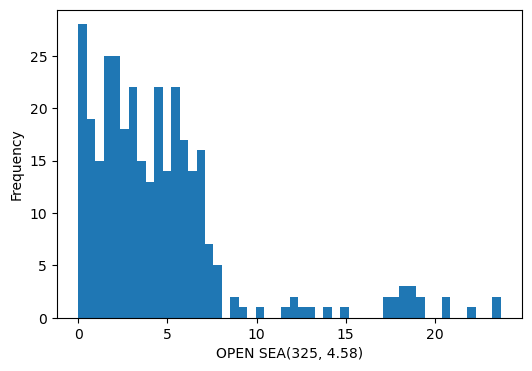

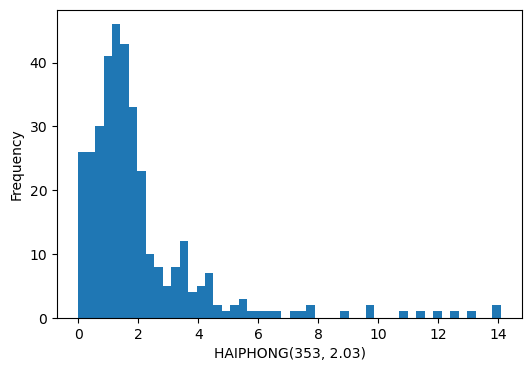

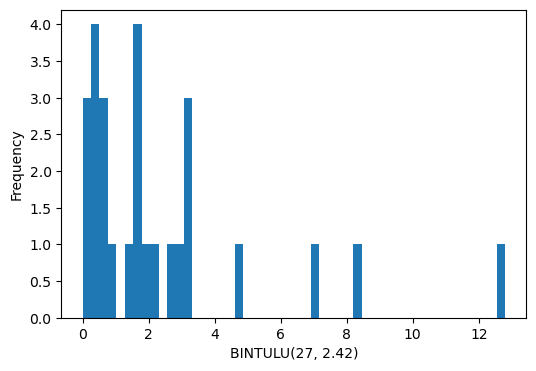

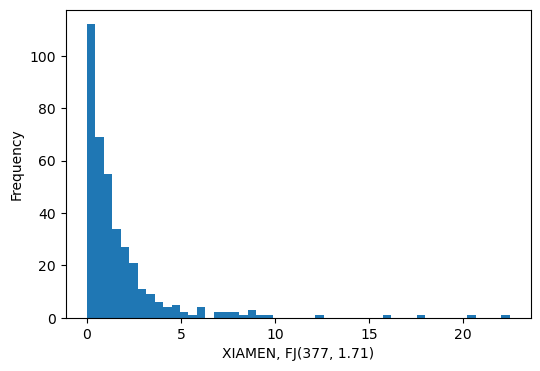

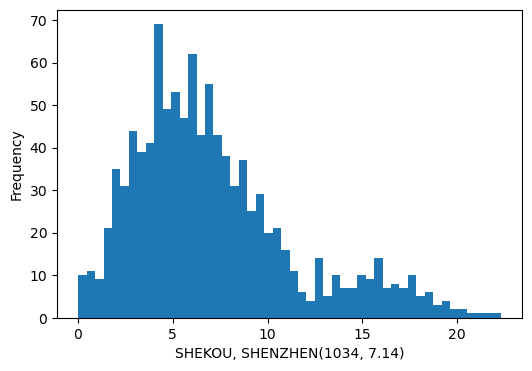

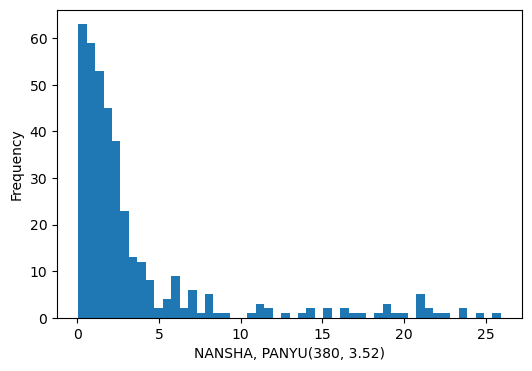

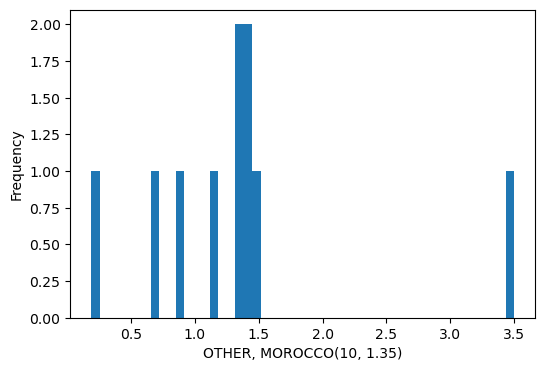

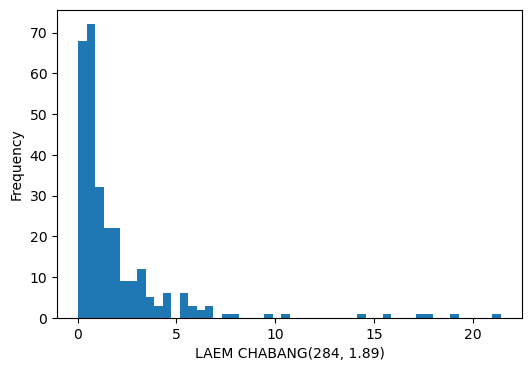

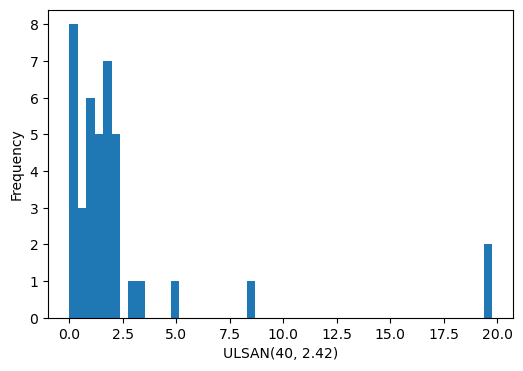

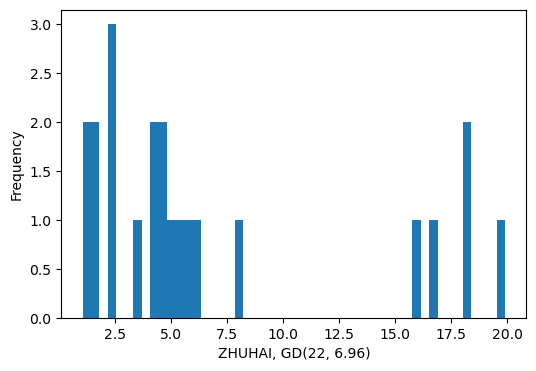

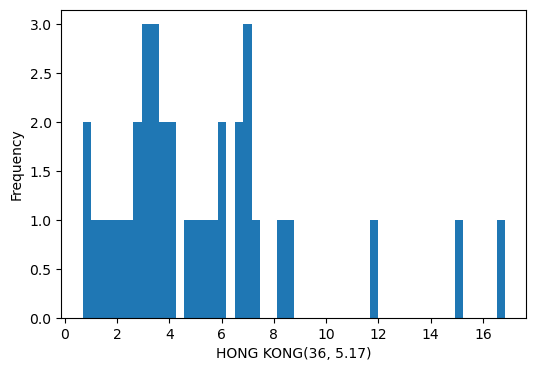

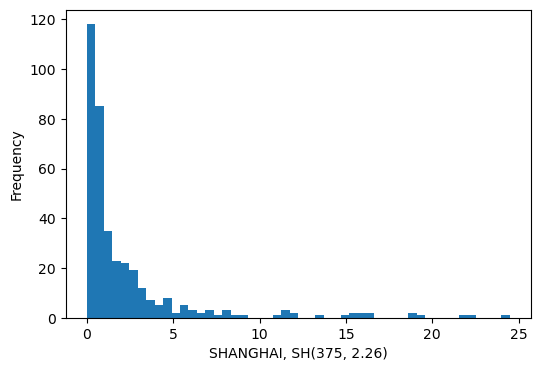

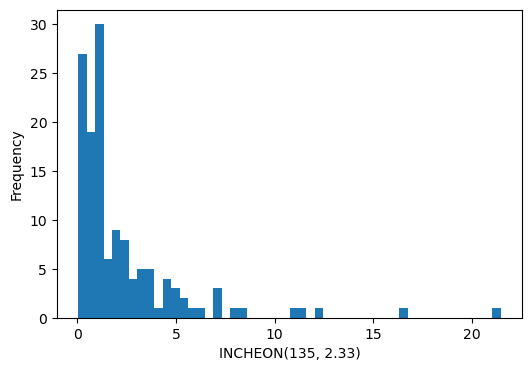

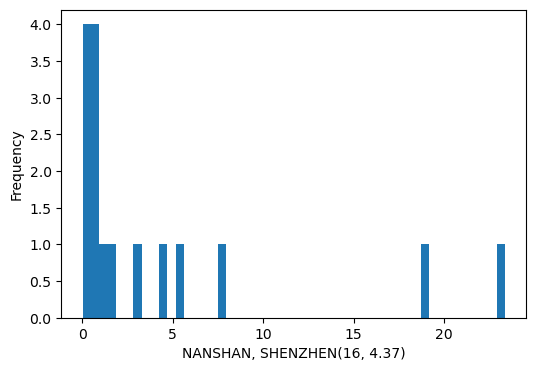

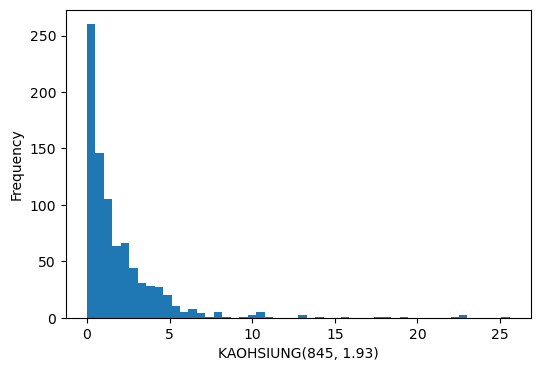

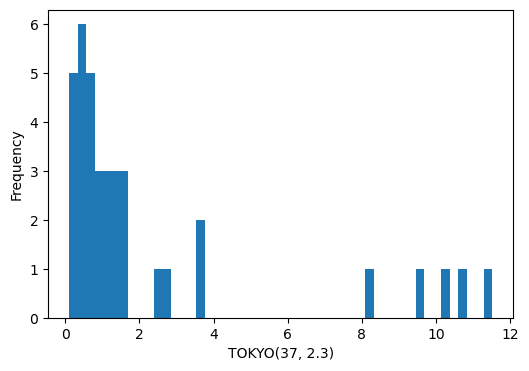

In [ ]:
import matplotlib.pyplot as plt
for port_name in unique_port_name:
    plt.figure(figsize=(6,4))
    figure_data = training_data[training_data["DUE_LAST_PORT"] == port_name]["predict_error"].dropna()
    plt.hist(figure_data, bins=50)
    plt.xlabel(f"{port_name}({len(figure_data)}, {round(predict_error[port_name], 2)})")
    plt.ylabel("Frequency")
    plt.show()


In [10]:
training_data

,ARRIVED_CALL_SIGN,ARRIVED_SHIP_TYPE,ARRIVED_AGENT_NAME,DUE_LAST_PORT,ARRIVED_ARRIVAL_TIME,DUE_ETA,ARRIVAL_DELAY,DEPARTED_SERVICE_TIME,pred,DUE_ETA_DAY,predicted_arrival_time,ATA,ETA,PTA,s,delta,adelta,predict_error
0,VRAR6,CONTAINER,COSCO SHIPPING CONTAINER LINE AGENCIES LIMITED,"SHEKOU, SHENZHEN",2024-04-01 01:54:00,2024-04-01 00:30:00,1.400000,11.133333,-7.412380,2024-04-01,2024-03-31 17:05:15.432642539,14.43,13.03,5.62,11.13,-5.498861,1.892237,8.81
1,C6AV9,CONTAINER,T.S. LINES LIMITED,"QINZHOU, GX",2024-04-01 05:23:00,2024-04-01 03:00:00,2.383333,8.016667,1.286392,2024-04-01,2024-04-01 04:17:11.012552188,17.92,15.53,16.82,8.02,1.908359,0.988082,1.10
2,H3OA,CONTAINER,EVERGREEN MARINE (HONG KONG) LTD,"ZHANJIANG, GD",2024-04-01 05:06:00,2024-04-01 04:00:00,1.100000,10.016667,4.184495,2024-04-01,2024-04-01 08:11:04.181768826,17.63,16.53,20.72,10.02,1.623408,0.012627,-3.09
3,BKWQ3,CONTAINER,CGW LOGISTICS CO LIMITED,MAOMING,2024-04-01 05:29:00,2024-04-01 05:00:00,0.483333,4.683333,1.460148,2024-04-01,2024-04-01 06:27:36.531935395,18.02,17.53,18.99,4.68,0.000000,0.000000,-0.97
4,A8MY7,CONTAINER,CMA CGM (HONG KONG) LIMITED,TAURANGA,2024-04-01 07:08:00,2024-04-01 06:00:00,1.133333,8.466667,-2.504239,2024-04-01,2024-04-01 03:29:44.740411725,19.67,18.53,16.03,8.47,2.796637,1.411340,3.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7828,3FQM7,CONTAINER,EVERGREEN MARINE (HONG KONG) LTD,"NANSHA, PANYU",2025-03-31 19:10:00,2025-03-31 17:30:00,1.666667,19.333333,-0.801791,2025-03-31,2025-03-31 16:41:53.553517952,30.35,28.69,27.88,19.33,-0.087060,1.648744,2.47
7829,V2HR3,CONTAINER,CMA CGM ASIA SHIPPING PTE. LTD.,OPEN SEA,2025-03-30 22:42:00,2025-03-31 18:00:00,-19.300000,7.766667,-13.754240,2025-03-31,2025-03-31 04:14:44.735693489,9.89,29.19,15.43,7.77,-17.200048,-23.753363,-5.54
7830,9V8501,CONTAINER,OOCL HONG KONG BRANCH,QINGDAO,2025-03-31 21:29:00,2025-03-31 21:30:00,-0.016667,14.983333,2.414679,2025-03-31,2025-03-31 23:54:52.843724614,32.67,32.69,35.10,14.98,1.692817,1.723526,-2.43
7831,5LLO4,CONTAINER,MEDITERRANEAN SHIPPING COMPANY (HONG KONG) LIM...,"OTHER, MALAYSIA",2025-04-01 00:06:00,2025-03-31 22:00:00,2.100000,30.533333,2.595316,2025-03-31,2025-04-01 00:35:43.136718082,35.29,33.19,35.78,30.53,1.169420,1.225619,-0.49


In [ ]:
# get training data
for m in range(1, 13):
    merge_previous_12_months(input_folder, output_folder, 2025, m)